# Tuning e early stopping

**Tema:** Aprendizado Supervisionado › Boosting

Este notebook fecha o módulo mostrando o que acontece SEM early stopping
(overfitting real, ao contrário de Random Forest), implementando early
stopping corretamente com um conjunto de validação separado, e comparando
o resultado final com Random Forest no mesmo problema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss
import xgboost as xgb

rng = np.random.default_rng(60)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Dataset e split em três partes: treino, validação (early stopping), teste

In [2]:
n = 4000
X = rng.normal(0, 1, (n, 10))
beta = rng.normal(0, 1, 10)
logit = X @ beta
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

X_treino, X_resto, y_treino, y_resto = train_test_split(X, y, test_size=0.4, random_state=0)
X_val, X_teste, y_val, y_teste = train_test_split(X_resto, y_resto, test_size=0.5, random_state=0)
print(f"treino: {len(X_treino)}   validação (early stopping): {len(X_val)}   "
      f"teste (nunca tocado até o fim): {len(X_teste)}")

treino: 2400   validação (early stopping): 800   teste (nunca tocado até o fim): 800


## 2. Sem early stopping: overfitting real, ao contrário de Random Forest

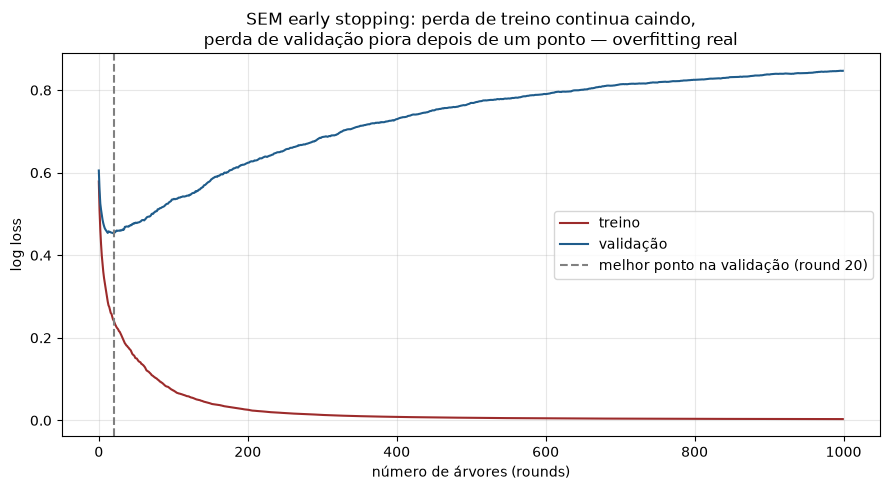

log loss de treino na última rodada    : 0.0032
log loss de validação na última rodada : 0.8468
log loss de validação no MELHOR round  : 0.4538


In [3]:
modelo_muitas_arvores = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.3, max_depth=5, random_state=0,
    eval_metric="logloss")
modelo_muitas_arvores.fit(
    X_treino, y_treino, eval_set=[(X_treino, y_treino), (X_val, y_val)], verbose=False)

resultados_eval = modelo_muitas_arvores.evals_result()
perda_treino = resultados_eval["validation_0"]["logloss"]
perda_validacao = resultados_eval["validation_1"]["logloss"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(perda_treino, color=VERMELHO, lw=1.5, label="treino")
ax.plot(perda_validacao, color=AZUL, lw=1.5, label="validação")
melhor_iteracao = np.argmin(perda_validacao)
ax.axvline(melhor_iteracao, color="gray", ls="--",
          label=f"melhor ponto na validação (round {melhor_iteracao})")
ax.set_xlabel("número de árvores (rounds)"); ax.set_ylabel("log loss")
ax.set_title("SEM early stopping: perda de treino continua caindo,\n"
             "perda de validação piora depois de um ponto — overfitting real")
ax.legend(); plt.tight_layout(); plt.show()

print(f"log loss de treino na última rodada    : {perda_treino[-1]:.4f}")
print(f"log loss de validação na última rodada : {perda_validacao[-1]:.4f}")
print(f"log loss de validação no MELHOR round  : {perda_validacao[melhor_iteracao]:.4f}")

## 3. Early stopping corretamente implementado

In [4]:
modelo_com_early_stopping = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.3, max_depth=5, random_state=0,
    eval_metric="logloss", early_stopping_rounds=20)
modelo_com_early_stopping.fit(
    X_treino, y_treino, eval_set=[(X_val, y_val)], verbose=False)

print(f"número de árvores efetivamente usadas: "
      f"{modelo_com_early_stopping.best_iteration + 1} (de 1000 permitidas)")

auc_sem_early_stopping = roc_auc_score(
    y_teste, modelo_muitas_arvores.predict_proba(X_teste)[:, 1])
auc_com_early_stopping = roc_auc_score(
    y_teste, modelo_com_early_stopping.predict_proba(X_teste)[:, 1])

print(f"\nAUC no teste, SEM early stopping (1000 árvores)      : "
      f"{auc_sem_early_stopping:.4f}")
print(f"AUC no teste, COM early stopping ({modelo_com_early_stopping.best_iteration + 1} árvores)"
      f"{'':>6s}: {auc_com_early_stopping:.4f}")

número de árvores efetivamente usadas: 21 (de 1000 permitidas)

AUC no teste, SEM early stopping (1000 árvores)      : 0.8392
AUC no teste, COM early stopping (21 árvores)      : 0.8510


> **Por que o conjunto de validação, não o de teste:** `early_stopping_rounds`
> decide QUANDO PARAR olhando para `eval_set`. Se `eval_set` fosse o
> conjunto de teste final, o número de árvores (um hiperparâmetro) teria
> sido escolhido espiando o teste — o mesmo vazamento do módulo 2, agora
> aplicado ao número de rounds de boosting. `X_teste` só aparece DEPOIS,
> para a avaliação final, e nunca antes.

## 4. Busca de hiperparâmetros combinada com early stopping

In [5]:
combinacoes = [
    {"learning_rate": 0.3, "max_depth": 3},
    {"learning_rate": 0.3, "max_depth": 8},
    {"learning_rate": 0.05, "max_depth": 3},
    {"learning_rate": 0.05, "max_depth": 8},
]

print(f"{'learning_rate':>14s} {'max_depth':>10s} {'nº árvores':>11s} {'AUC validação':>14s}")
print("-" * 54)
melhor_config, melhor_auc_val = None, -1
for config in combinacoes:
    modelo = xgb.XGBClassifier(
        n_estimators=1000, random_state=0, eval_metric="logloss",
        early_stopping_rounds=20, **config)
    modelo.fit(X_treino, y_treino, eval_set=[(X_val, y_val)], verbose=False)
    auc_val = roc_auc_score(y_val, modelo.predict_proba(X_val)[:, 1])
    print(f"{config['learning_rate']:>14.2f} {config['max_depth']:>10d} "
          f"{modelo.best_iteration + 1:>11d} {auc_val:>14.4f}")
    if auc_val > melhor_auc_val:
        melhor_auc_val, melhor_config = auc_val, config

print(f"\nmelhor configuração (por AUC de VALIDAÇÃO): {melhor_config}")

modelo_final = xgb.XGBClassifier(
    n_estimators=1000, random_state=0, eval_metric="logloss",
    early_stopping_rounds=20, **melhor_config)
modelo_final.fit(X_treino, y_treino, eval_set=[(X_val, y_val)], verbose=False)
auc_final_teste = roc_auc_score(y_teste, modelo_final.predict_proba(X_teste)[:, 1])
print(f"AUC no TESTE (nunca usado até agora) com a config escolhida: {auc_final_teste:.4f}")

 learning_rate  max_depth  nº árvores  AUC validação
------------------------------------------------------
          0.30          3          26         0.8847
          0.30          8           8         0.8553


          0.05          3         243         0.8838


          0.05          8          64         0.8637

melhor configuração (por AUC de VALIDAÇÃO): {'learning_rate': 0.3, 'max_depth': 3}
AUC no TESTE (nunca usado até agora) com a config escolhida: 0.8544


## 5. Comparação final: boosting ajustado vs. Random Forest "de fábrica"

In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_treino, y_treino)
auc_rf = roc_auc_score(y_teste, rf.predict_proba(X_teste)[:, 1])

print(f"{'modelo':<32s} {'AUC no teste':>14s}")
print("-" * 48)
print(f"{'Random Forest (hiperparâmetros padrão)':<32s} {auc_rf:>14.4f}")
print(f"{'XGBoost ajustado + early stopping':<32s} {auc_final_teste:>14.4f}")

modelo                             AUC no teste
------------------------------------------------
Random Forest (hiperparâmetros padrão)         0.8448
XGBoost ajustado + early stopping         0.8544


**A comparação final resume o módulo inteiro:** boosting bem ajustado
(taxa de aprendizado, profundidade, early stopping) tende a igualar ou
superar Random Forest — mas exige todo esse cuidado adicional. Random
Forest, com hiperparâmetros padrão, já entrega um resultado razoável quase
sem ajuste — a diferença de robustez a hiperparâmetros mal escolhidos que
o `teoria.pdf` menciona.

## O que levar deste notebook

- Sem early stopping, boosting sobreajusta de verdade — a perda de
  validação piora depois de um ponto, mesmo com a de treino continuando a
  cair.
- Early stopping deve olhar para um conjunto de validação, nunca para o
  teste final — o mesmo princípio de vazamento de hiperparâmetro dos
  módulos anteriores.
- Boosting bem ajustado é competitivo ou superior a Random Forest, ao
  custo de mais cuidado no ajuste — a escolha entre os dois depende de
  quanto tempo/expertise há disponível para esse ajuste.

→ Próximo: o notebook de **exercícios** do módulo — e o encerramento do
tema de Aprendizado Supervisionado.